<a href="https://colab.research.google.com/github/eldhosekroy/churn_prediction/blob/main/churn_rp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Corrected import for plotting
import seaborn as sns
import os



In [3]:
base_dir = os.getcwd()

input_dir = base_dir

enrolled_file = os.path.join(input_dir, 'Endrolled & registred.xlsx')

enrolled = pd.read_excel(enrolled_file)

enrolled.head(3)

,Contact Id,Contact Owner.id,Contact Owner,First Name,Last Name,Email Opt Out,college Name.id,college Name,Track Interested,Tag,...,Gender,Year of Graduation,Experience,Test,Followup Email,Invoice,Mode of Program Joined,Program Location,Region,Whatsapp Number
0,zcrm_560042000000440092,zcrm_560042000000283001,SalesPerson-2,NaN,AJSAL Mohammed T S,False,NaN,NaN,Python Full stack,NaN,...,Male,NaN,NaN,False,False,Yes,NaN,NaN,NaN,NaN
1,zcrm_560042000000466061,zcrm_560042000000283001,SalesPerson-2,NaN,Abhishek R J,False,NaN,NaN,Datascience,NaN,...,NaN,2022.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN
2,zcrm_560042000000565094,zcrm_560042000000331113,SalesPerson-9,Alan,Thomas,False,NaN,NaN,NaN,NaN,...,Male,2023.0,NaN,False,False,Yes,NaN,NaN,NaN,NaN


Unregistered candidates: 190
Registered candidates: 1084
Enrolled candidates: 1274


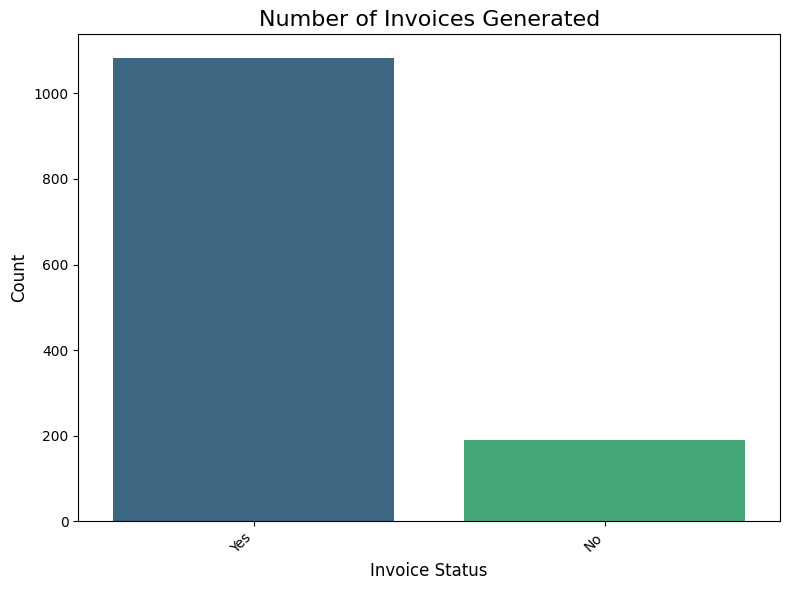

In [4]:
enrolled['Invoice'] = enrolled['Invoice'].fillna('No')
enrolled['Invoice'] = enrolled['Invoice'].replace('yes', 'Yes')

invoice_counts = enrolled['Invoice'].value_counts()
registered_candidates = invoice_counts.get('Yes', 0)
enrolled_candidates = invoice_counts.sum()
unregistered_candidates = enrolled_candidates - registered_candidates

print("Unregistered candidates:", unregistered_candidates)
print("Registered candidates:", invoice_counts.get('Yes', 0))
print("Enrolled candidates:", invoice_counts.sum())

# Create a bar plot
plt.figure(figsize=(8, 6))
# Addressing the FutureWarning by explicitly setting hue and legend
sns.barplot(x=invoice_counts.index, y=invoice_counts.values, hue=invoice_counts.index, palette='viridis', legend=False)
plt.title('Number of Invoices Generated', fontsize=16)
plt.xlabel('Invoice Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability if many categories
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Candidates not joined in any program: 239
Joined candidates: 1035


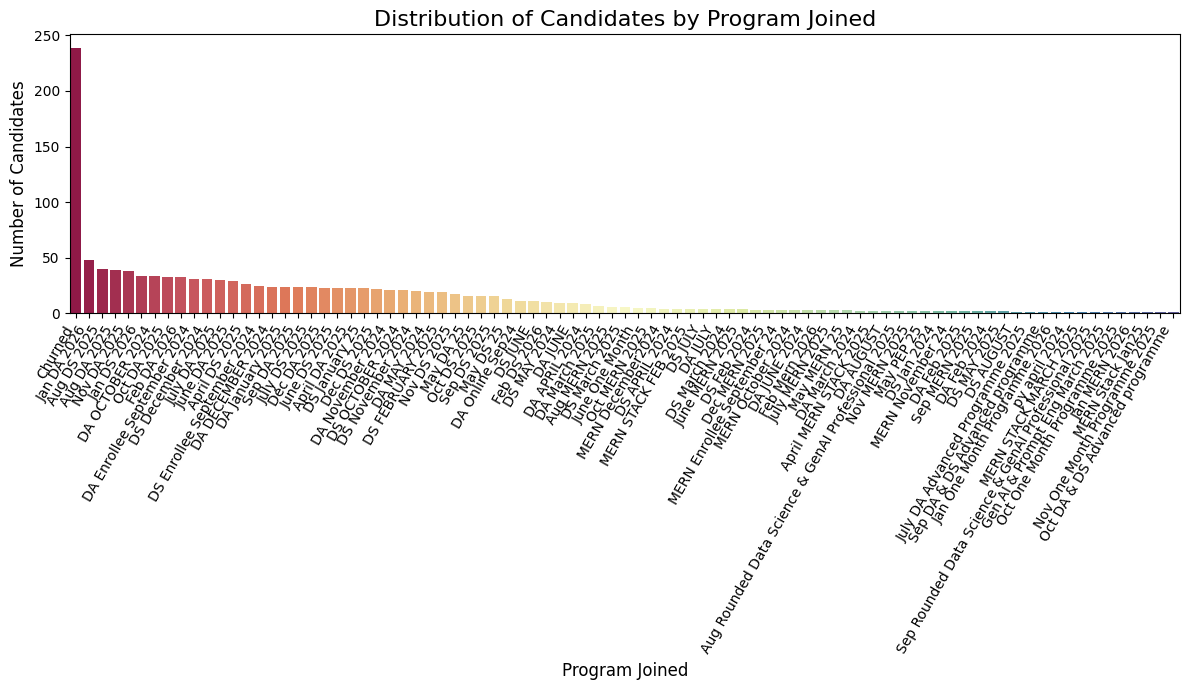

In [5]:
# Count the occurrences of each unique value in the 'Program Joined' column
enrolled['Program Joined'] = enrolled['Program Joined'].fillna('Churned')
program_joined_counts = enrolled['Program Joined'].value_counts()

not_joined_candidates = program_joined_counts.get('Churned', 0)
total_candidates = program_joined_counts.sum()
joined_candidates = total_candidates - not_joined_candidates

print("Candidates not joined in any program:", not_joined_candidates)
print("Joined candidates:", joined_candidates)

# Create a bar plot for 'Program Joined'
plt.figure(figsize=(12, 7)) # Increase figure size for better readability if many programs
sns.barplot(x=program_joined_counts.index, y=program_joined_counts.values, hue=program_joined_counts.index, palette='Spectral', legend=False)
plt.title('Distribution of Candidates by Program Joined', fontsize=16)
plt.xlabel('Program Joined', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=60, ha='right') # Rotate x-axis labels to prevent overlap
plt.tight_layout() # Adjust layout
plt.show()

Candidates who joined a program AND have an invoice (Active candidates): 980
Churned candidates (Invoice Yes, Program Joined Churned): 104
Joined candidates without invoice: 55
Inactive candidates (Invoice No, Program Joined Churned): 135


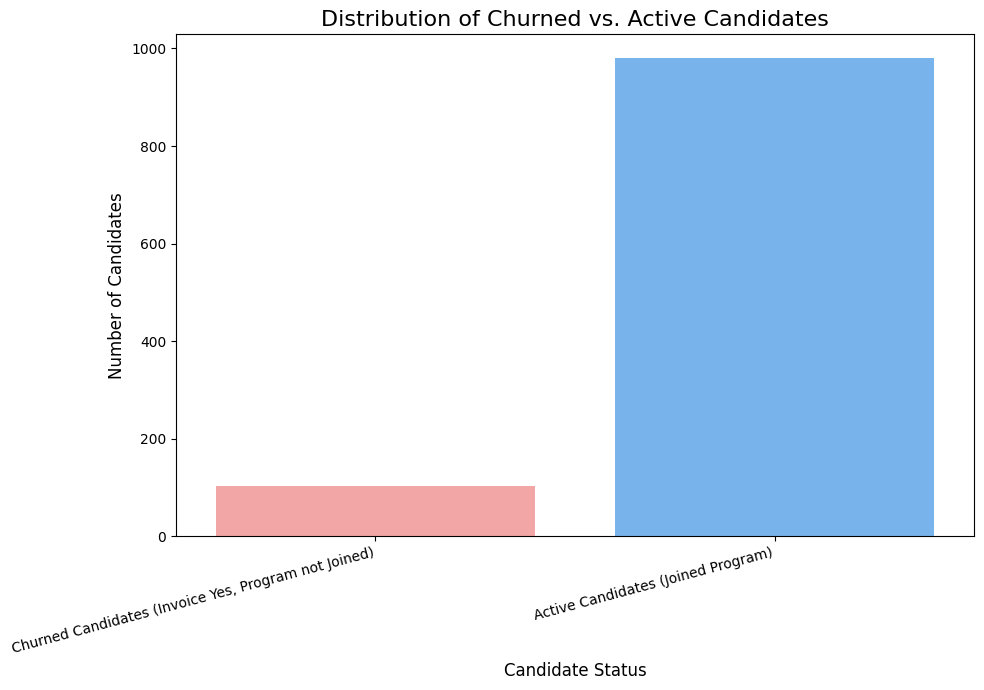

In [6]:
program_joined_with_invoice_count = enrolled[(enrolled['Program Joined'] != 'Churned') & (enrolled['Invoice'] == 'Yes')].shape[0]
print(f"Candidates who joined a program AND have an invoice (Active candidates): {program_joined_with_invoice_count}")

churned_program_invoice_status = enrolled[enrolled['Program Joined'] == 'Churned']['Invoice'].value_counts()
churned_candidates = churned_program_invoice_status.get('Yes', 0)

print("Churned candidates (Invoice Yes, Program Joined Churned):", churned_candidates)

churned_candidates_count = churned_program_invoice_status.get('Yes', 0)
active_candidates_count = program_joined_with_invoice_count # Updated to use program_joined_with_invoice_count

candidate_status_data = pd.Series({
    'Churned Candidates (Invoice Yes, Program not Joined)': churned_candidates_count,
    'Active Candidates (Joined Program)': active_candidates_count
})

joined_no_invoice = joined_candidates - active_candidates_count
print("Joined candidates without invoice:", joined_no_invoice)

non_active_candidates = churned_program_invoice_status.get('No', 0)
print("Inactive candidates (Invoice No, Program Joined Churned):", non_active_candidates)


plt.figure(figsize=(10, 7))
sns.barplot(x=candidate_status_data.index, y=candidate_status_data.values, hue=candidate_status_data.index, palette=['#ff9999', '#66b3ff'], legend=False)
plt.title('Distribution of Churned vs. Active Candidates', fontsize=16)
plt.xlabel('Candidate Status', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Programs Joined Details

## Year-wise Course Distribution

In [17]:
import re
import pandas as pd

# First, standardize the 'Program Joined' column as requested.
def standardize_program_joined_text(program_string):
    if pd.isna(program_string) or program_string == 'Churned':
        return program_string

    program_string = str(program_string)

    # 1. Standardize month names (full to short form, and ensure proper case)
    month_mapping = {
        'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
        'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
        'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
    }
    for full, short in month_mapping.items():
        program_string = re.sub(r'\b' + full + r'\b', short, program_string, flags=re.IGNORECASE)

    # Ensure month abbreviations are capitalized (e.g., "jan" -> "Jan")
    program_string = re.sub(r'\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b', lambda x: x.group(0).capitalize(), program_string, flags=0)

    # 2. Standardize common program keywords/abbreviations (case-insensitive search, consistent replacement)
    program_string = re.sub(r'\bprogramme\b', 'Program', program_string, flags=re.IGNORECASE)
    # Fix for 'Enrolleeee' issue: replace 'enroll' or 'enrollee' with 'Enrollee' (word boundary for accurate replacement)
    program_string = re.sub(r'\b(enroll|enrollee)\b', 'Enrollee', program_string, flags=re.IGNORECASE)

    # Specific course abbreviations - these should be uppercase
    program_string = re.sub(r'\bmern stack\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bmern\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytics\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytic\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata science\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata sci\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bfull stack\b', 'FS', program_string, flags=re.IGNORECASE)

    # Standardize 'One Month Program' variations
    program_string = re.sub(r'\b(One Month Programme|One Month Program)\b', 'One Month Program', program_string, flags=re.IGNORECASE)

    # Clean up extra spaces
    program_string = ' '.join(program_string.split())

    # Final capitalization for desired format (e.g., "DA May 2024"), then fix abbreviations
    program_string = program_string.title()
    program_string = program_string.replace('Da', 'DA').replace('Ds', 'DS').replace('Mern', 'MERN').replace('Fs', 'FS')
    # Ensure Enrollee keeps its capitalization
    program_string = program_string.replace('Enrollee', 'Enrollee')
    program_string = program_string.replace('One Month Program', 'One Month Program') # Keep as is after title()

    return program_string

# Apply this initial standardization to the 'Program Joined' column
enrolled['Program Joined Standardized'] = enrolled['Program Joined'].apply(standardize_program_joined_text)


# Now define and apply the function to extract year and a *very* clean course name
def extract_year_and_course(program_string):
    if pd.isna(program_string) or program_string == 'Churned':
        return None, 'Churned'

    program_string = str(program_string)

    # Extract year
    year_match = re.search(r'\b(202[0-9]|203[0-9]|204[0-9])\b', program_string)
    year = int(year_match.group(1)) if year_match else None

    # Clean string to extract raw course name by removing year and known month abbreviations
    cleaned_course_name = program_string
    cleaned_course_name = re.sub(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', '', cleaned_course_name, flags=0)
    cleaned_course_name = re.sub(r'\b(202[0-9]|203[0-9]|204[0-9])\b', '', cleaned_course_name)

    # More aggressively remove common extra words that are not part of the core course name
    # Added 'Bootcamp', 'Course', 'Classes' for more thorough cleaning
    cleaned_course_name = re.sub(r'\b(Program|Enrollee|One Month|Advanced|Training|Bootcamp|Course|Classes)\b', '', cleaned_course_name, flags=re.IGNORECASE)
    cleaned_course_name = re.sub(r' & ', '&', cleaned_course_name) # Standardize ampersand

    cleaned_course_name = cleaned_course_name.strip()
    cleaned_course_name = ' '.join(cleaned_course_name.split()) # Remove multiple spaces
    cleaned_course_name = cleaned_course_name.upper() # Convert to uppercase for final standardization

    # Map remaining raw course names to standardized forms
    course_name_mapping = {
        'DA': 'DA',
        'DS': 'DS',
        'MERN': 'MERN',
        'FS': 'FS',
        'WEB DEV': 'WEB DEV',
        'BA': 'BA',
        'DM': 'DM',
        'ML': 'ML',
        'DA&DS': 'DA&DS',
        'DATA ANALYTICS': 'DA',
        'DATA SCIENCE': 'DS',
        'FULL STACK': 'FS',
        'MERN STACK': 'MERN',
        'ADVANCED': 'ADVANCED',
        'EE': 'ENROLLEE', # Still keeping this as a fallback, but aggressive cleaning should reduce its use
        'DA ENROLLEE': 'DA' # Explicitly map this pattern to 'DA'
    }

    final_course_name = course_name_mapping.get(cleaned_course_name, cleaned_course_name)

    if final_course_name == '':
        final_course_name = 'UNSPECIFIED'

    return year, final_course_name

# Apply the year and course extraction on the newly standardized 'Program Joined Standardized' column
enrolled[['Program_Year', 'Course_Name']] = enrolled['Program Joined Standardized'].apply(lambda x: pd.Series(extract_year_and_course(x)))

# Convert 'Program_Year' to nullable integer type to remove decimal part while retaining NaN values
enrolled['Program_Year'] = enrolled['Program_Year'].astype(pd.Int64Dtype())

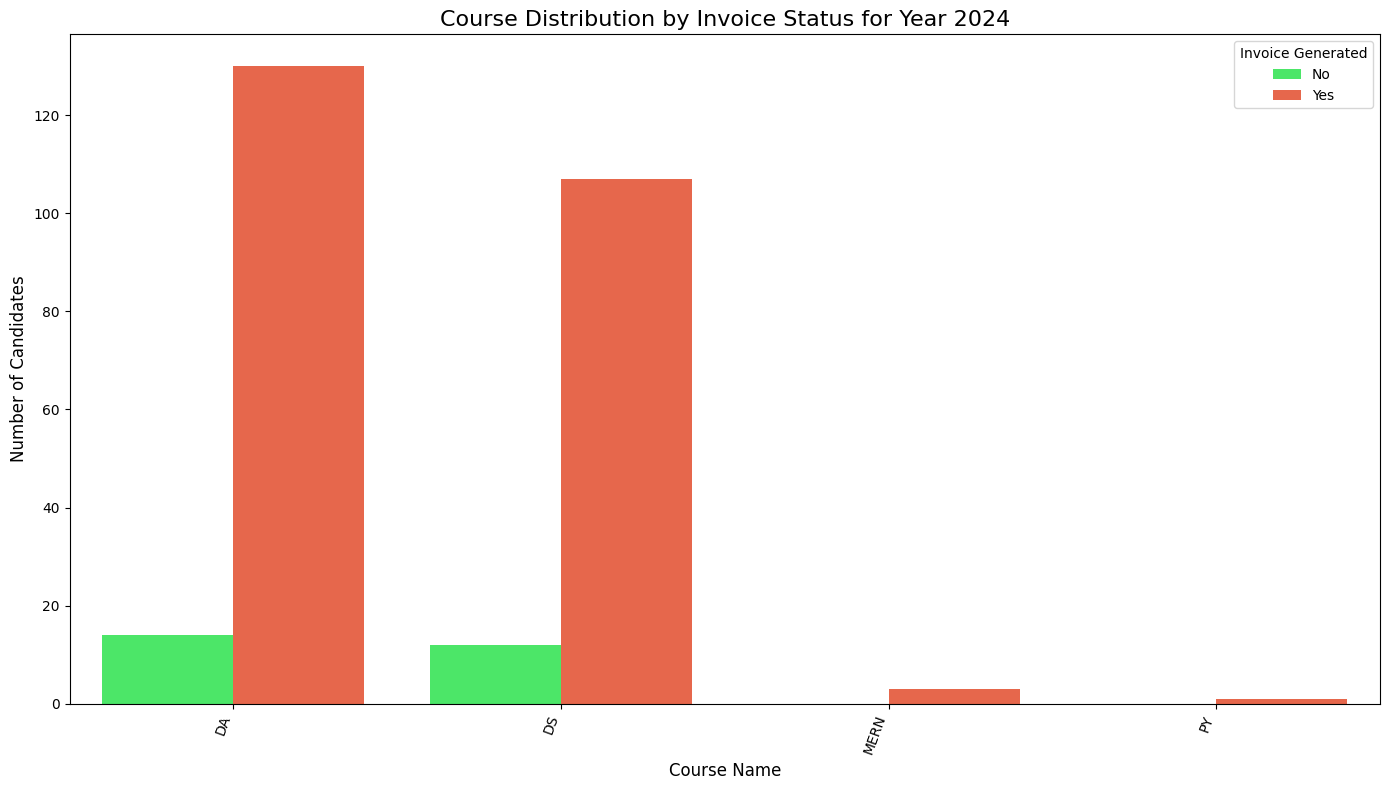

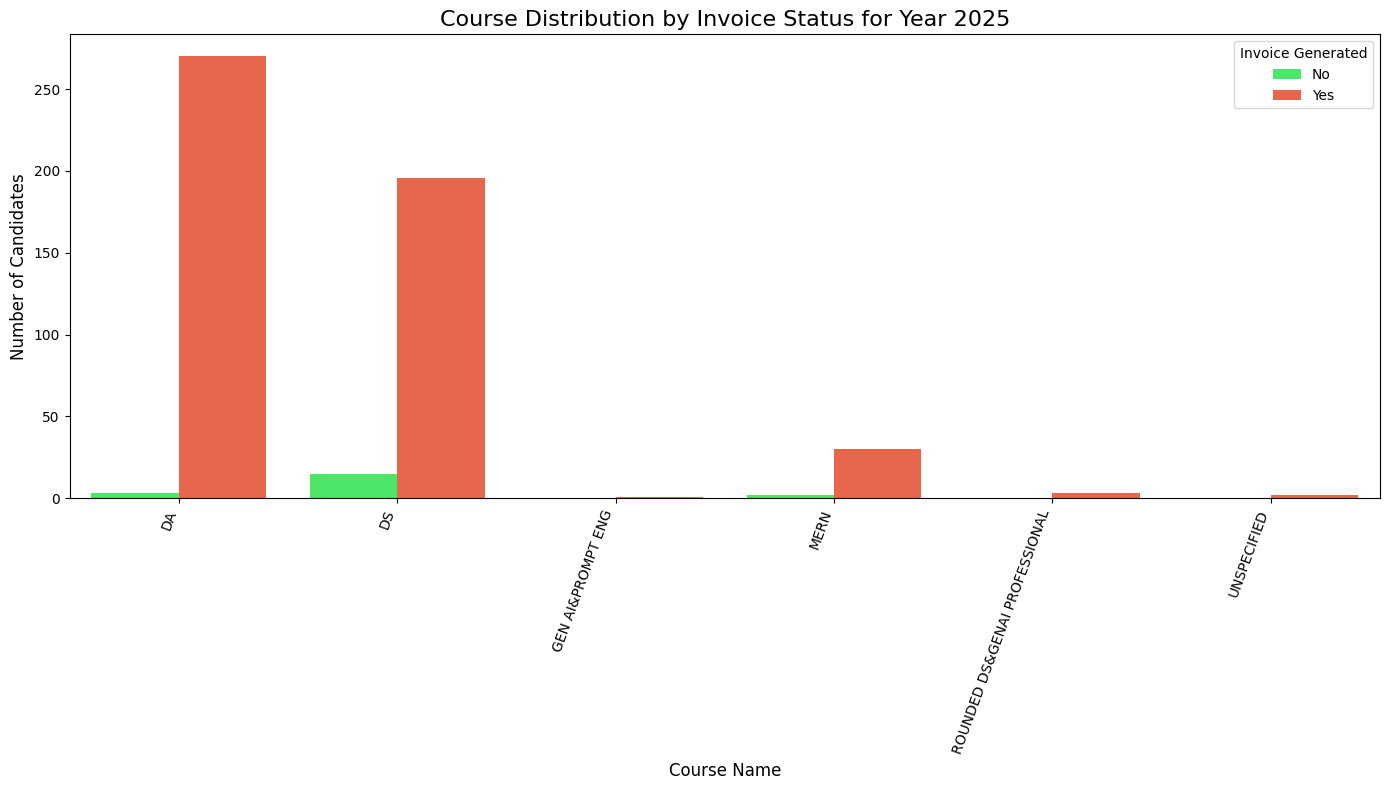

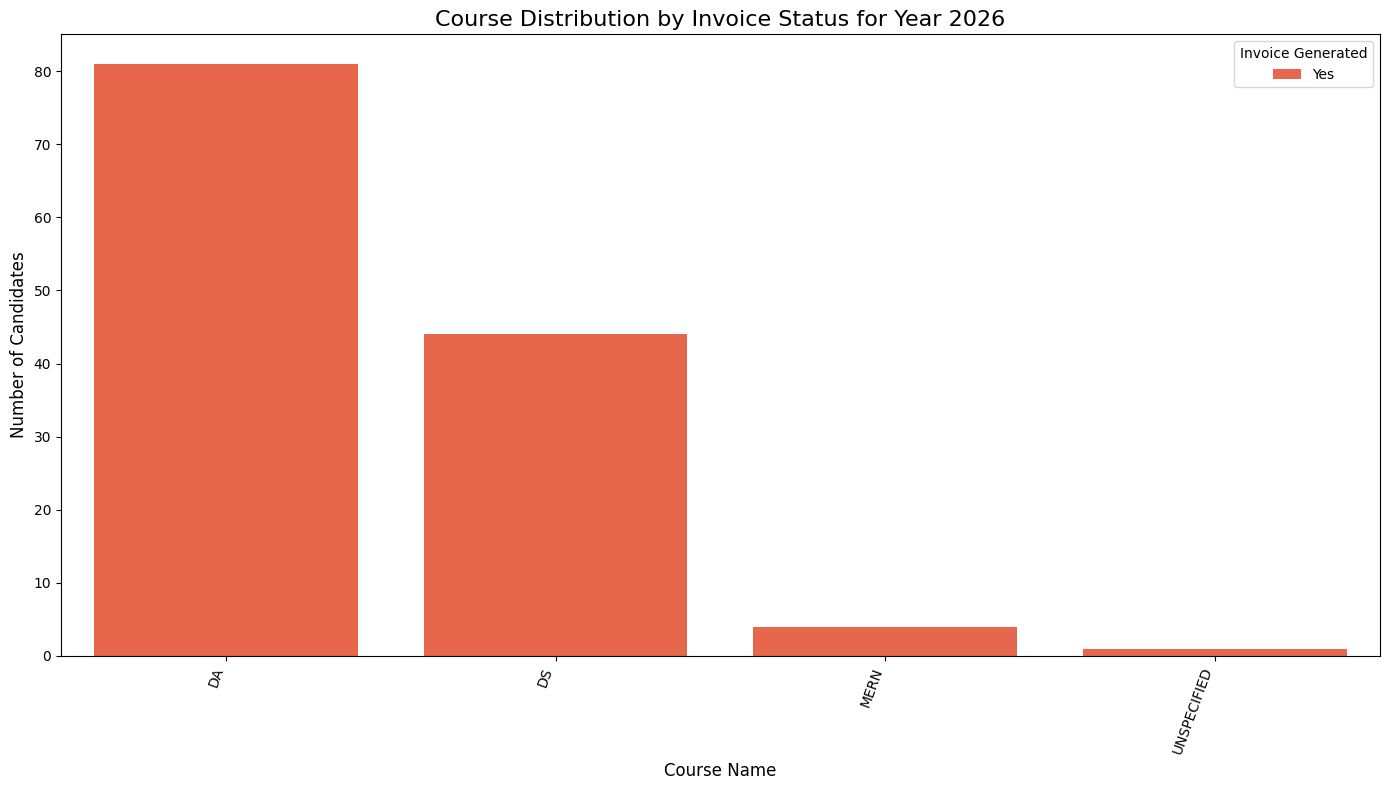

In [18]:
# Filter out 'Churned' courses and entries with NaN years for visualization
# Assuming 'enrolled' DataFrame, 'Course_Name', 'Program_Year', and 'Invoice' are already prepared from previous steps.
program_data_for_plot = enrolled[enrolled['Course_Name'] != 'Churned'].dropna(subset=['Program_Year']).copy()
program_data_for_plot['Program_Year'] = program_data_for_plot['Program_Year'].astype(int)

# Get unique years for plotting
unique_years_for_plot = sorted(program_data_for_plot['Program_Year'].unique())

for year in unique_years_for_plot:
    year_data = program_data_for_plot[program_data_for_plot['Program_Year'] == year]

    # Group by Course_Name and Invoice status, then count
    course_invoice_counts = year_data.groupby(['Course_Name', 'Invoice']).size().unstack(fill_value=0)

    if not course_invoice_counts.empty:
        # Prepare data for seaborn.barplot with hue
        # 'level_1' is the default name for the stacked column if no other name is specified. It corresponds to 'Invoice'.
        plot_df = course_invoice_counts.stack().reset_index(name='Count')

        plt.figure(figsize=(14, 8)) # Increased figure size for better readability
        sns.barplot(
            data=plot_df,
            x='Course_Name',
            y='Count',
            hue='Invoice', # Use the 'Invoice' column directly for hue
            palette={'Yes': '#FF5733', 'No': '#33FF57'} # Using brighter, more distinct colors
        )
        plt.title(f'Course Distribution by Invoice Status for Year {year}', fontsize=16)
        plt.xlabel('Course Name', fontsize=12)
        plt.ylabel('Number of Candidates', fontsize=12)
        plt.xticks(rotation=70, ha='right')
        plt.legend(title='Invoice Generated') # Add a legend for Invoice Status
        plt.tight_layout()
        plt.show()
    else:
        print(f'No course data available for year {year}.')


### Program Growth by Invoice Status Across Years

The following plots visualize the yearly growth for each program, showing the trend of 'Invoice Yes' and 'Invoice No' counts over the available years. Each subplot is dedicated to a specific course, making it easy to observe how the number of candidates with and without invoices has changed from year to year. The plots use darker colors and thicker lines for improved visibility.

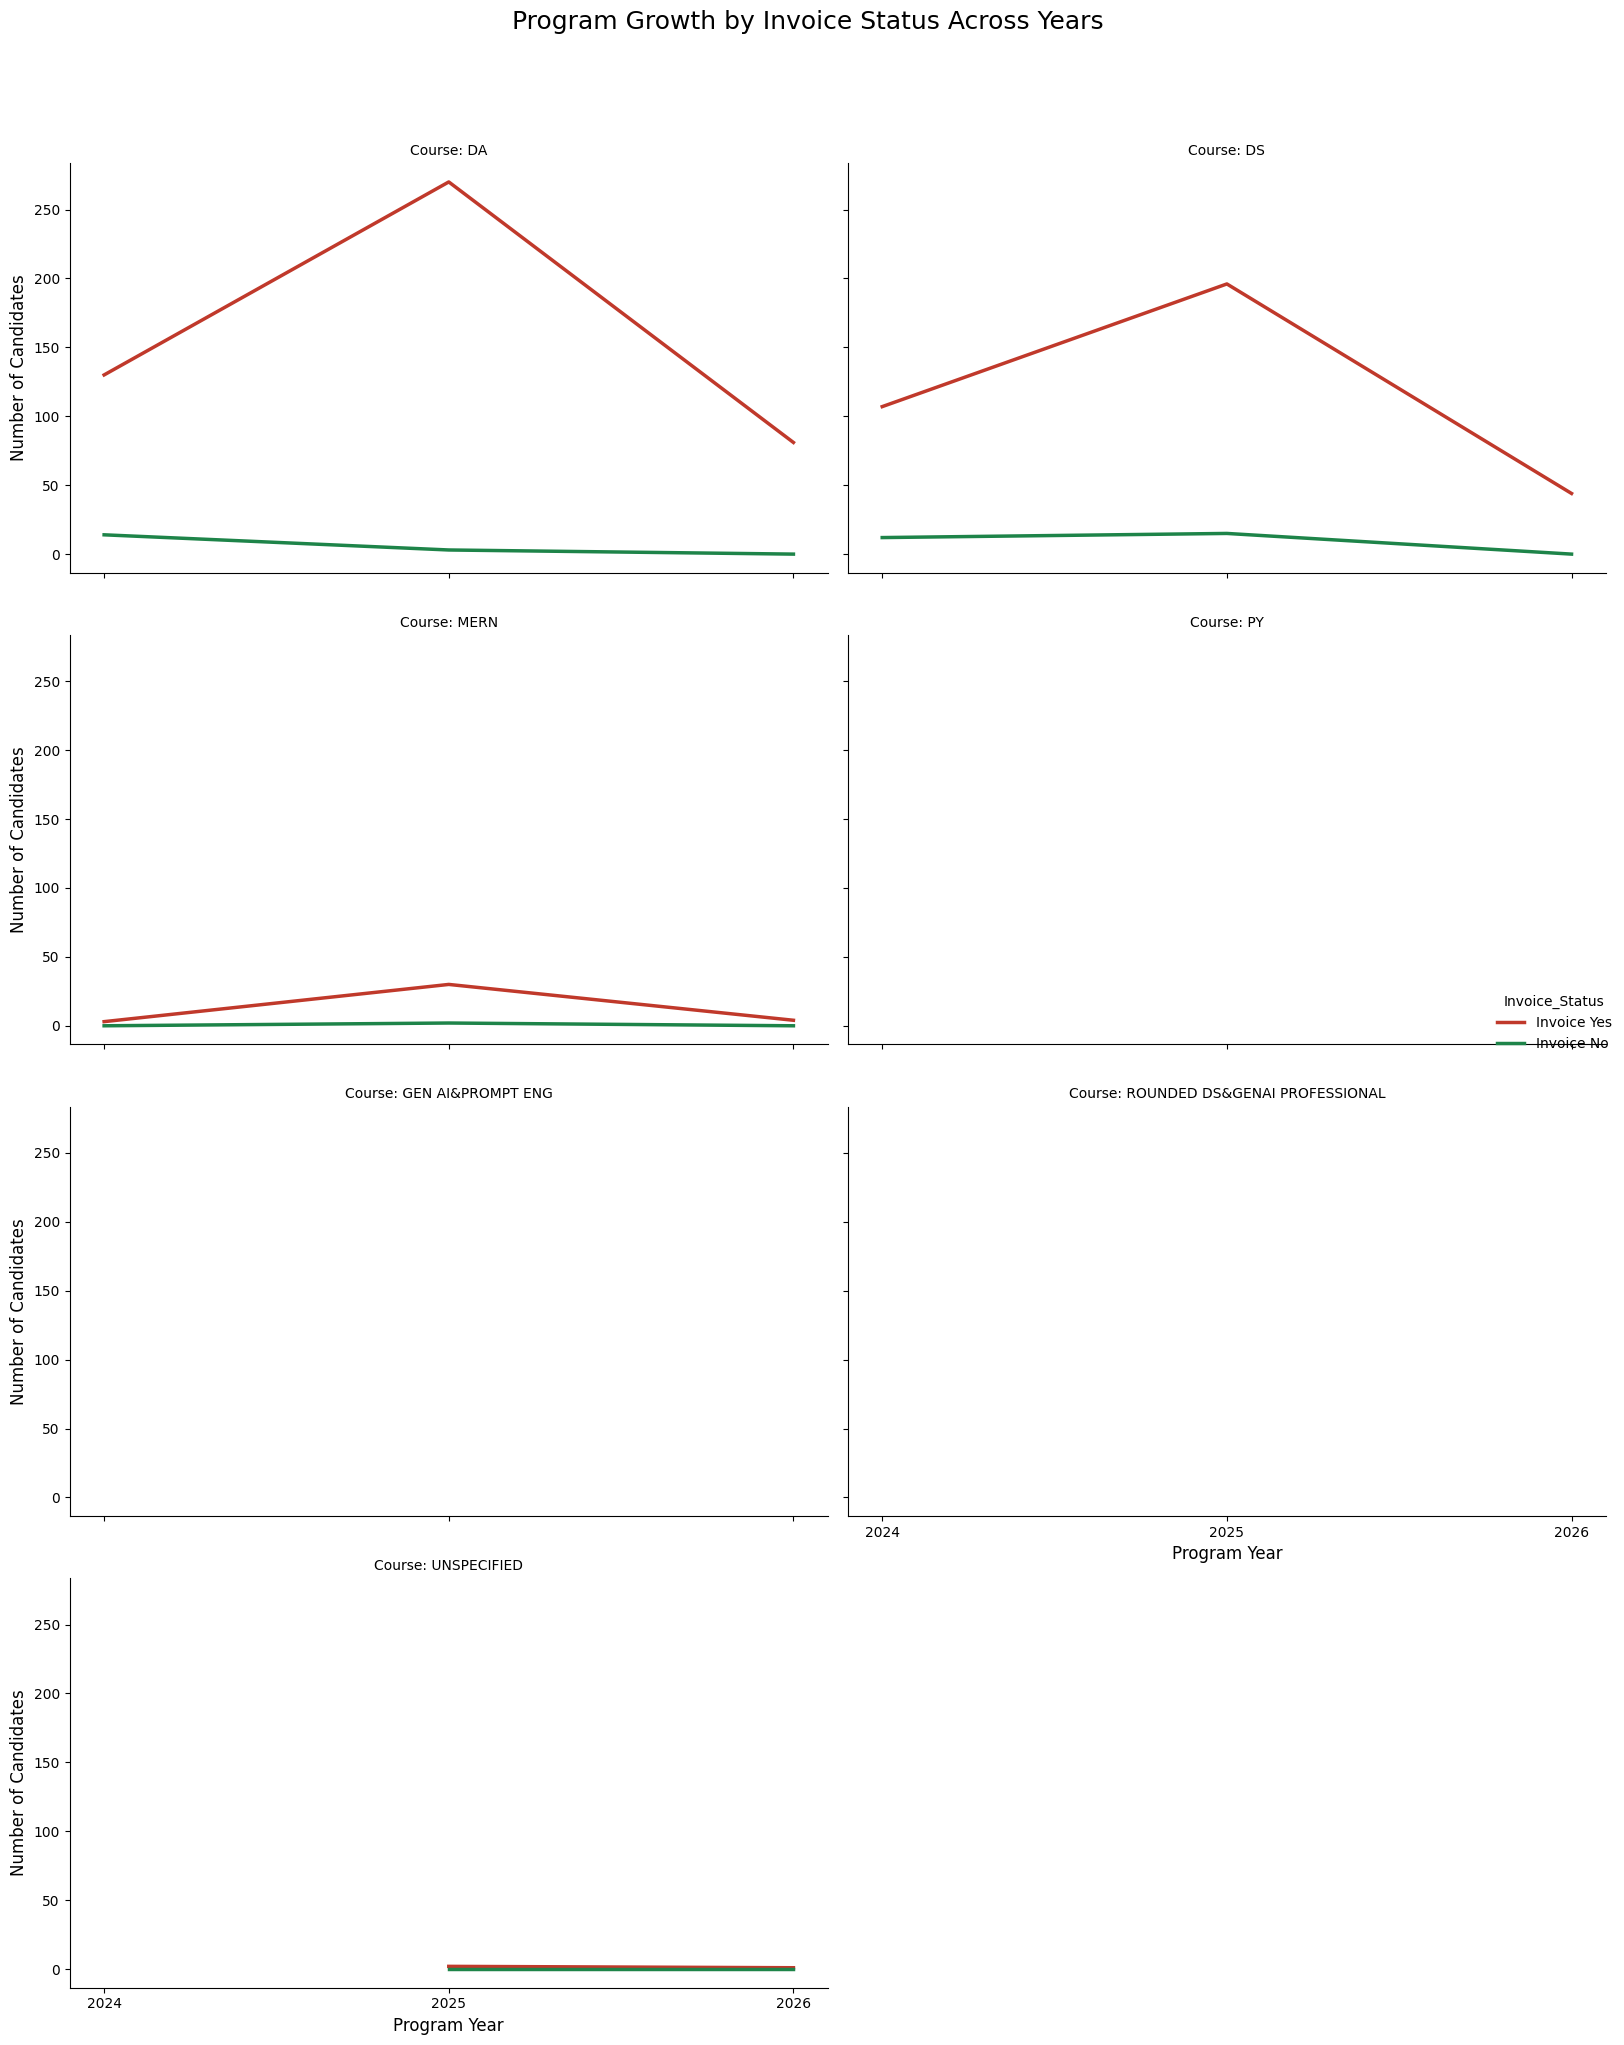

In [21]:
# Aggregate data by Program_Year, Course_Name, and Invoice status
program_year_invoice_counts = program_data_for_plot.groupby(['Program_Year', 'Course_Name', 'Invoice']).size().unstack(fill_value=0).reset_index()

# Rename columns for clarity in the plot
program_year_invoice_counts = program_year_invoice_counts.rename(columns={'Yes': 'Invoice_Yes_Count', 'No': 'Invoice_No_Count'})

# Melt the DataFrame to a long format suitable for line plotting with hue
plot_df_long = program_year_invoice_counts.melt(
    id_vars=['Program_Year', 'Course_Name'],
    value_vars=['Invoice_Yes_Count', 'Invoice_No_Count'],
    var_name='Invoice_Status_Raw',
    value_name='Count'
)

# Clean up Invoice_Status for better legend labels
plot_df_long['Invoice_Status'] = plot_df_long['Invoice_Status_Raw'].replace(
    {'Invoice_Yes_Count': 'Invoice Yes', 'Invoice_No_Count': 'Invoice No'}
)

# Create a faceted line plot with darker palette, thicker lines, and larger fonts
# Increased height and aspect for a larger plot size
g = sns.relplot(
    data=plot_df_long,
    x='Program_Year',
    y='Count',
    hue='Invoice_Status',
    col='Course_Name', # Facet by Course_Name to get one plot per program
    kind='line',
    col_wrap=2, # Wrap columns after 2 plots for even larger individual plot sizes
    height=5, aspect=1.5, # Adjusted for larger plot size
    palette={'Invoice Yes': '#C0392B', 'Invoice No': '#1E8449'}, # Darker, more distinct colors
    linewidth=2.5 # Make lines thicker
)

# Customize titles and labels with larger font sizes
g.set_axis_labels("Program Year", "Number of Candidates", fontsize=12)
g.set_titles("Course: {col_name}", fontsize=14)
g.fig.suptitle('Program Growth by Invoice Status Across Years', y=1.02, fontsize=18) # Increase super title font size

# Get unique years from the data to use as x-axis ticks
unique_program_years = sorted(plot_df_long['Program_Year'].unique())

# Set x-ticks for each subplot to display only whole years
for ax in g.axes.flat:
    ax.set_xticks(unique_program_years)
    ax.set_xticklabels([str(int(year)) for year in unique_program_years])

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle from overlapping
plt.show()

In [20]:
enrolled.head(3)

,Contact Id,Contact Owner.id,Contact Owner,First Name,Last Name,Email Opt Out,college Name.id,college Name,Track Interested,Tag,...,Test,Followup Email,Invoice,Mode of Program Joined,Program Location,Region,Whatsapp Number,Program Joined Standardized,Program_Year,Course_Name
0,zcrm_560042000000440092,zcrm_560042000000283001,SalesPerson-2,NaN,AJSAL Mohammed T S,False,NaN,NaN,Python Full stack,NaN,...,False,False,Yes,NaN,NaN,NaN,NaN,Churned,<NA>,Churned
1,zcrm_560042000000466061,zcrm_560042000000283001,SalesPerson-2,NaN,Abhishek R J,False,NaN,NaN,Datascience,NaN,...,False,False,No,NaN,NaN,NaN,NaN,DA May 2024,2024,DA
2,zcrm_560042000000565094,zcrm_560042000000331113,SalesPerson-9,Alan,Thomas,False,NaN,NaN,NaN,NaN,...,False,False,Yes,NaN,NaN,NaN,NaN,Churned,<NA>,Churned
